# Goal: To understand decline of viewership of XYZ Show,

Variable,Explaination
Views_show,Number of times the show was viewed
Visitors,"Number of visitors who browsed the platform, but not necessarily watched a video. "
Views_platform,Number of times a video was viewed on the platform
Ad_impression,Proxy for marketing budget. Represents number of impressions generated by ads
Cricket_match_india,"If a cricket match was being played. 1 indicates that there was a match on a given day, 0 indicates there wasn't"
Character_A,"Describes presence of Character A. 1 indicates that character A was present in the episode, 0 indicates she/he wasn't"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("mediacompany.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 80 non-null     object 
 1   Views_show           80 non-null     int64  
 2   Visitors             80 non-null     int64  
 3   Views_platform       80 non-null     int64  
 4   Ad_impression        80 non-null     int64  
 5   Cricket_match_india  80 non-null     int64  
 6   Character_A          80 non-null     int64  
 7   Unnamed: 7           0 non-null      float64
dtypes: float64(1), int64(6), object(1)
memory usage: 5.1+ KB


In [5]:
df

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Unnamed: 7
0,3/1/2017,183738,1260228,1706478,1060860448,0,0,NaN
1,3/2/2017,193763,1270561,1690727,1031846645,0,0,NaN
2,3/3/2017,210479,1248183,1726157,1010867575,0,0,NaN
3,3/4/2017,240061,1492913,1855353,1079194579,1,0,NaN
4,3/5/2017,446314,1594712,2041418,1357736987,0,0,NaN
...,...,...,...,...,...,...,...,...
75,5/15/2017,313945,1808684,2226788,1398052759,1,0,NaN
76,5/16/2017,185689,1814227,2199844,1311961223,1,0,NaN
77,5/17/2017,142260,1755803,2225752,1248266254,1,0,NaN
78,5/18/2017,135871,1749654,2302789,1284859759,1,0,NaN


In [6]:
df.drop("Unnamed: 7", axis=1, inplace=True)

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,2017-03-01,183738,1260228,1706478,1060860448,0,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0
...,...,...,...,...,...,...,...
75,2017-05-15,313945,1808684,2226788,1398052759,1,0
76,2017-05-16,185689,1814227,2199844,1311961223,1,0
77,2017-05-17,142260,1755803,2225752,1248266254,1,0
78,2017-05-18,135871,1749654,2302789,1284859759,1,0


In [9]:
df["Date"].dt.month.value_counts()

Date
3    31
4    30
5    19
Name: count, dtype: int64

In [10]:
df["Character_A"].value_counts()

Character_A
0    50
1    30
Name: count, dtype: int64

In [11]:
x = df[(df["Cricket_match_india"] == 1)]["Visitors"].sum()

In [12]:
y = df["Visitors"].sum()

In [13]:
(df[(df["Cricket_match_india"] == 1)]["Views_show"].sum()) / df["Views_show"].sum()

np.float64(0.08675227587194148)

In [14]:
df

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,2017-03-01,183738,1260228,1706478,1060860448,0,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0
...,...,...,...,...,...,...,...
75,2017-05-15,313945,1808684,2226788,1398052759,1,0
76,2017-05-16,185689,1814227,2199844,1311961223,1,0
77,2017-05-17,142260,1755803,2225752,1248266254,1,0
78,2017-05-18,135871,1749654,2302789,1284859759,1,0


In [15]:
num_vars = ["Visitors", "Views_platform", "Ad_impression"]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

<Figure size 900x700 with 0 Axes>

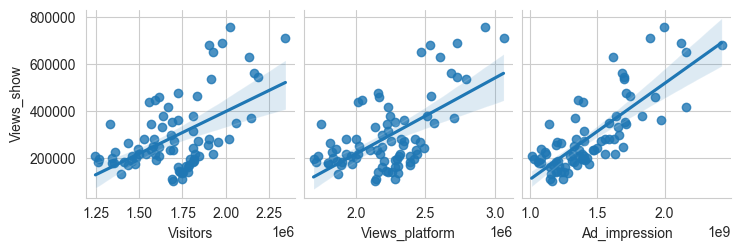

In [17]:
plt.figure(figsize=(9, 7))
sns.pairplot(
    df,
    x_vars=num_vars,
    y_vars="Views_show",
    kind="reg",
)
plt.show()

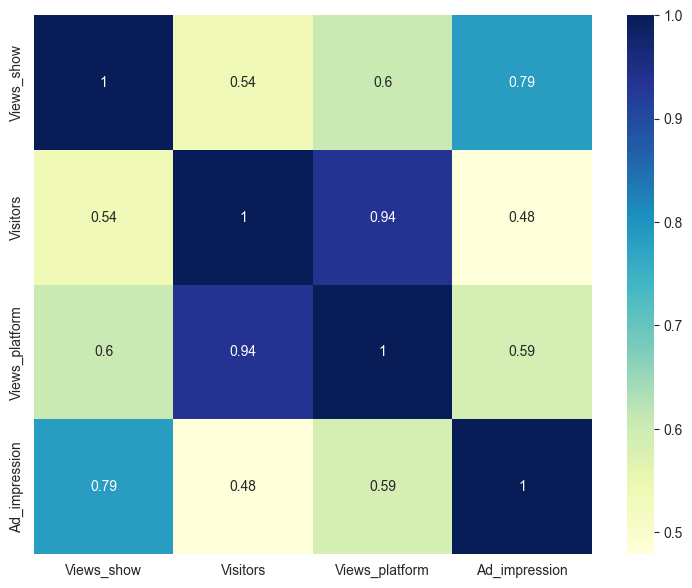

In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    df[["Views_show", "Visitors", "Views_platform", "Ad_impression"]].corr(),
    cmap="YlGnBu",
    annot=True,
)
plt.show()

In [19]:
dir(df["Date"].dt)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__frozen',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_add_delegate_accessors',
 '_constructor',
 '_delegate_method',
 '_delegate_property_get',
 '_delegate_property_set',
 '_dir_additions',
 '_dir_deletions',
 '_freeze',
 '_get_values',
 '_hidden_attrs',
 '_parent',
 '_reset_cache',
 'as_unit',
 'ceil',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'floor',
 'freq',
 'hour',
 'is_leap_year',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'is_quarter_start',
 'is_year_end',
 'is_year_start',
 'isocalendar',
 'microsecond',


In [20]:
df["Day"] = df["Date"].dt.day_name()

In [21]:
df["Weekend"] = df["Day"].map(lambda x: 1 if x == "Saturday" or x == "Sunday" else 0)

In [22]:
df

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Day,Weekend
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,Wednesday,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,Thursday,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,Friday,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,Saturday,1
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,Sunday,1
...,...,...,...,...,...,...,...,...,...
75,2017-05-15,313945,1808684,2226788,1398052759,1,0,Monday,0
76,2017-05-16,185689,1814227,2199844,1311961223,1,0,Tuesday,0
77,2017-05-17,142260,1755803,2225752,1248266254,1,0,Wednesday,0
78,2017-05-18,135871,1749654,2302789,1284859759,1,0,Thursday,0


In [23]:
weekend_sum = df[df["Weekend"] == 1]["Views_platform"].sum()
weekday_sum = df[df["Weekend"] == 0]["Views_platform"].sum()
print(
    f"Weekend views: {weekend_sum}, Weekday views {weekday_sum}, ratio: {weekend_sum/weekday_sum}"
)

Weekend views: 53306130, Weekday views 124485943, ratio: 0.4282100349273974


In [24]:
# 53,306,130 124,485,943

In [25]:
df["Day_as_number"] = df["Date"].dt.day  # todo correct me please

In [26]:
df["Day_as_number"]

0      1
1      2
2      3
3      4
4      5
      ..
75    15
76    16
77    17
78    18
79    19
Name: Day_as_number, Length: 80, dtype: int32

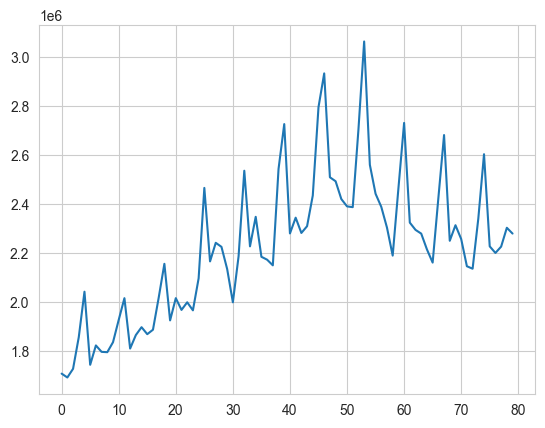

In [27]:
plt.plot(df["Views_platform"])

In [28]:
df["Date"].dt.dayofweek

0     2
1     3
2     4
3     5
4     6
     ..
75    0
76    1
77    2
78    3
79    4
Name: Date, Length: 80, dtype: int32

In [29]:
import statsmodels.api as sm

In [30]:
df["Weekday"] = df["Day"].map(lambda x: 0 if x == "Saturday" or x == "Sunday" else 1)

In [31]:
df

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Day,Weekend,Day_as_number,Weekday
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,Wednesday,0,1,1
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,Thursday,0,2,1
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,Friday,0,3,1
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,Saturday,1,4,0
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,Sunday,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...
75,2017-05-15,313945,1808684,2226788,1398052759,1,0,Monday,0,15,1
76,2017-05-16,185689,1814227,2199844,1311961223,1,0,Tuesday,0,16,1
77,2017-05-17,142260,1755803,2225752,1248266254,1,0,Wednesday,0,17,1
78,2017-05-18,135871,1749654,2302789,1284859759,1,0,Thursday,0,18,1


In [32]:
df_train, df_test = train_test_split(df, train_size=0.7, random_state=100)

In [33]:
# Model 1 views on weekends
X_train = df_train[
    [
        "Views_show",
        "Views_platform",
        "Ad_impression",
        "Cricket_match_india",
        "Character_A",
        "Weekend",
    ]
]
y_train = df_train["Visitors"]

In [34]:
X_train_sm = sm.add_constant(X_train)
lm = sm.OLS(y_train, X_train_sm).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:               Visitors   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     198.6
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.29e-32
Time:                        11:20:09   Log-Likelihood:                -681.75
No. Observations:                  56   AIC:                             1378.
Df Residuals:                      49   BIC:                             1392.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -2.107e+05   7

In [35]:
# Model 2 weekday vs visitors
X = df["Weekday"]
y = df["Visitors"]
X_sm = sm.add_constant(X)
weekday_model = sm.OLS(y, X_sm).fit()
print(weekday_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Visitors   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     22.22
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.04e-05
Time:                        11:20:09   Log-Likelihood:                -1091.1
No. Observations:                  80   AIC:                             2186.
Df Residuals:                      78   BIC:                             2191.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.875e+06   4.38e+04     42.845      0.0

In [36]:
# Model 3 weeend vs visitors
X = df["Weekend"]
y = df["Visitors"]
X_sm = sm.add_constant(X)
weekday_model = sm.OLS(y, X_sm).fit()
print(weekday_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Visitors   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     22.22
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.04e-05
Time:                        11:20:09   Log-Likelihood:                -1091.1
No. Observations:                  80   AIC:                             2186.
Df Residuals:                      78   BIC:                             2191.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.632e+06   2.69e+04     60.578      0.0

In [37]:
X_train_sm = sm.add_constant(X_train)
lm = sm.OLS(y_train, X_train_sm).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:               Visitors   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     198.6
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.29e-32
Time:                        11:20:09   Log-Likelihood:                -681.75
No. Observations:                  56   AIC:                             1378.
Df Residuals:                      49   BIC:                             1392.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -2.107e+05   7

In [39]:
np.mean(df["Views_show"])

np.float64(289902.625)

In [40]:
np.median(df["Views_show"])

np.float64(235807.0)

In [44]:
np.quantile(df["Views_show"], 0.75)

np.float64(350079.0)

In [45]:
np.percentile(df["Views_show"], 50)

np.float64(235807.0)

In [ ]:
# to plot 2 lines to show actual distribution vs predicted
# c = [i for i in range(1, 81, 1)]
# fig = plt.figure()
# plt.plot(c, y, color="blue", linewidth=2.5, linestyle="-")
# plt.plot(c, , color="red", linewidth=2.5, linestyle="-")
# fig.suptitle("Actual and Predicted", fontsize=20)  # Plot heading
# plt.xlabel("Index", fontsize=18)  # X-label
# plt.ylabel("Views", fontsize=16)  # Y-label

In [70]:
df = pd.read_csv(
    "https://media-doselect.s3.amazonaws.com/generic/OzvzVqK4pgg4x7qEadoZMRyVR/insurance.csv"
)

In [47]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [62]:
def categories(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"


df["bmi_group"] = df["bmi"].map(lambda x: categories(x))
print(df.head())

   age     sex     bmi  children smoker     region      charges   bmi_group
0   19  female  27.900         0    yes  southwest  16884.92400  Overweight
1   18    male  33.770         1     no  southeast   1725.55230       Obese
2   28    male  33.000         3     no  southeast   4449.46200       Obese
3   33    male  22.705         0     no  northwest  21984.47061      Normal
4   32    male  28.880         0     no  northwest   3866.85520  Overweight


In [74]:
df["smoker"] = df["smoker"].map(lambda x: 1 if x == "yes" else 0)

In [84]:
print(float(round(df[["smoker", "bmi"]].corr()["bmi"][0], 4)))

/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/25936501.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(round(df[['smoker','bmi']].corr()['bmi'][0],4))


0.0038

In [85]:
print(float(round(df[["age", "bmi"]].corr()["bmi"][0], 4)))

0.1093


/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/3664260097.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(float(round(df[['age','bmi']].corr()['bmi'][0],4)))


In [86]:
print(float(round(df[["charges", "bmi"]].corr()["bmi"][0], 4)))

0.1983


/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/476083086.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(float(round(df[['charges','bmi']].corr()['bmi'][0],4)))


In [87]:
df = pd.read_csv(
    "https://media-doselect.s3.amazonaws.com/generic/B5yO4wkEbQk4dVGn8140yV1bx/insurance_encoded.csv"
)

In [88]:
df

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges,BMI_group
0,0,19,0,27.900,0,1,3,16884.92400,3
1,1,18,1,33.770,1,0,2,1725.55230,2
2,2,28,1,33.000,3,0,2,4449.46200,2
3,3,33,1,22.705,0,0,1,21984.47061,1
4,4,32,1,28.880,0,0,1,3866.85520,3
...,...,...,...,...,...,...,...,...,...
1333,1333,50,1,30.970,3,0,1,10600.54830,2
1334,1334,18,0,31.920,0,0,0,2205.98080,2
1335,1335,18,0,36.850,0,0,2,1629.83350,2
1336,1336,21,0,25.800,0,0,3,2007.94500,3


In [96]:
print(float(round(df[["bmi", "smoker"]].corr()["smoker"][0], 4)))

print(round(df[["age", "smoker"]].corr()["smoker"][0], 4))
print(float(round(df[["charges", "smoker"]].corr()["smoker"][0], 4)))

0.0038
-0.025
0.7873


/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/60909773.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(float(round(df[['bmi','smoker']].corr()['smoker'][0],4)))
/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/60909773.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(round(df[['age','smoker']].corr()['smoker'][0],4))
/var/folders/pp/g9t7w39n3ks5_g6ygrlq5zlw0000gn/T/ipykernel_4174/60909773.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

In [97]:
print("{:0.4f}".format(round(df["smoker"].corr(df["bmi"]), 4)))
print("{:0.4f}".format(round(df["smoker"].corr(df["age"]), 4)))
print("{:0.4f}".format(round(df["smoker"].corr(df["charges"]), 4)))

0.0038
-0.0250
0.7873
